Precomputing H(k) and Z components (no tilt γ=0) ...
Done precomputing.
Integrating over 3D BZ for each μ ...
μ = -5.00 done


/tmp/ipython-input-2939244484.py:102: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp(beta * (E - mu)) + 1.0)


μ = -4.83 done
μ = -4.66 done
μ = -4.49 done
μ = -4.32 done
μ = -4.15 done
μ = -3.98 done
μ = -3.81 done
μ = -3.64 done
μ = -3.47 done
μ = -3.31 done
μ = -3.14 done
μ = -2.97 done
μ = -2.80 done
μ = -2.63 done
μ = -2.46 done
μ = -2.29 done
μ = -2.12 done
μ = -1.95 done
μ = -1.78 done
μ = -1.61 done
μ = -1.44 done
μ = -1.27 done
μ = -1.10 done
μ = -0.93 done
μ = -0.76 done
μ = -0.59 done
μ = -0.42 done
μ = -0.25 done
μ = -0.08 done
μ = 0.08 done
μ = 0.25 done
μ = 0.42 done
μ = 0.59 done
μ = 0.76 done
μ = 0.93 done
μ = 1.10 done
μ = 1.27 done
μ = 1.44 done
μ = 1.61 done
μ = 1.78 done
μ = 1.95 done
μ = 2.12 done
μ = 2.29 done
μ = 2.46 done
μ = 2.63 done
μ = 2.80 done
μ = 2.97 done
μ = 3.14 done
μ = 3.31 done
μ = 3.47 done
μ = 3.64 done
μ = 3.81 done
μ = 3.98 done
μ = 4.15 done
μ = 4.32 done
μ = 4.49 done
μ = 4.66 done
μ = 4.83 done
μ = 5.00 done


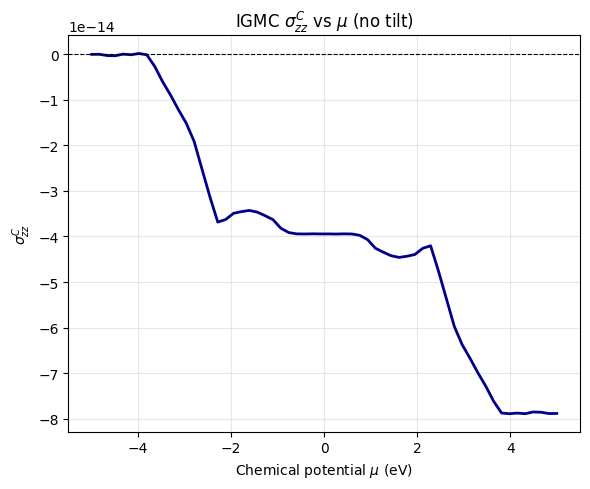

In [ ]:


import numpy as np
import matplotlib.pyplot as plt



# Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
sigma0 = np.eye(2, dtype=complex)

# Parameters
gamma = 0.0   # no Tilt
t = 1.0       # Hopping amplitude
tx = 0.5      # x-direction hopping
m = 2.0       # Mass term / inversion breaking
k0 = np.pi / 2

# ---- Hamiltonian pieces ----
def N0_of_k(kx, ky, kz):
    # With gamma = 0, this contributes nothing (no tilt)
    return gamma * (np.cos(2*kx) - np.cos(k0)) * (np.cos(kz) - np.cos(k0))

def Nx_of_k(kx, ky, kz):
    return m * (1 - np.cos(kz)**2 - np.cos(ky)) + 2.0 * tx * (np.cos(kx) - np.cos(k0))

def Ny_of_k(kx, ky, kz):
    return -2.0 * t * np.sin(ky)

def Nz_of_k(kx, ky, kz):
    return -2.0 * t * np.cos(kz)

def H_k(kx, ky, kz):
    Nx, Ny, Nz, N0 = Nx_of_k(kx, ky, kz), Ny_of_k(kx, ky, kz), Nz_of_k(kx, ky, kz), N0_of_k(kx, ky, kz)
    return Nx*sx + Ny*sy + Nz*sz + N0*sigma0

# ---- Derivatives of H ----
def dH_dkx(kx, ky, kz, dk=1e-5):
    return (H_k(kx+dk, ky, kz) - H_k(kx-dk, ky, kz)) / (2*dk)

def dH_dky(kx, ky, kz, dk=1e-5):
    return (H_k(kx, ky+dk, kz) - H_k(kx, ky-dk, kz)) / (2*dk)

def dH_dkz(kx, ky, kz, dk=1e-5):
    return (H_k(kx, ky, kz+dk) - H_k(kx, ky, kz-dk)) / (2*dk)

# ---- Zeeman Berry curvature tensor ----
def zeeman_Z_components(kx, ky, kz, dk=1e-5):
    H = H_k(kx, ky, kz)
    evals, evecs = np.linalg.eigh(H)
    u_minus, u_plus = evecs[:, 0], evecs[:, 1]
    E_minus, E_plus = evals
    denom = E_plus - E_minus if abs(E_plus - E_minus) > 1e-12 else 1e-12

    dHx, dHy, dHz = dH_dkx(kx, ky, kz, dk), dH_dky(kx, ky, kz, dk), dH_dkz(kx, ky, kz, dk)
    r_mp = 1j * np.array([
        np.vdot(u_minus, dHx @ u_plus),
        np.vdot(u_minus, dHy @ u_plus),
        np.vdot(u_minus, dHz @ u_plus)
    ]) / denom
    r_pm = np.conjugate(r_mp)

    sigma_list = [sx, sy, sz]
    sigma_pm = np.array([np.vdot(u_plus, S @ u_minus) for S in sigma_list])
    sigma_mp = np.array([np.vdot(u_minus, S @ u_plus) for S in sigma_list])

    Z = np.zeros((3, 3), dtype=complex)
    for a in range(3):
        for b in range(3):
            Z[a, b] = 1j * (r_mp[a]*sigma_pm[b] - r_pm[a]*sigma_mp[b])
    return Z

# ------------------------------------------------------------
#  MAIN SIGMA^C COMPUTATION
# ------------------------------------------------------------

component = 'zz'
index_map = {'x': 0, 'y': 1, 'z': 2}
i, j = index_map[component[0]], index_map[component[1]]

# --- k-grid ---
N = 150
kx_vals = np.linspace(-np.pi, np.pi, N)
ky_vals = np.linspace(-np.pi, np.pi, N)
kz_vals = np.linspace(-np.pi, np.pi, N)
dk = ((kx_vals[1]-kx_vals[0]) *
      (ky_vals[1]-ky_vals[0]) *
      (kz_vals[1]-kz_vals[0])) / (2*np.pi)**3

kx_grid, ky_grid, kz_grid = np.meshgrid(kx_vals, ky_vals, kz_vals, indexing='ij')
kx_flat, ky_flat, kz_flat = kx_grid.ravel(), ky_grid.ravel(), kz_grid.ravel()
npoints = kx_flat.size

# --- Fermi–Dirac ---
kB = 8.617333262e-5  # eV/K
T = 0.01

def fermi(E, mu, T):
    if T == 0:
        return (E < mu).astype(float)
    beta = 1.0 / (kB * T)
    return 1.0 / (np.exp(beta * (E - mu)) + 1.0)

# --- Precompute all energies and Zeeman tensors ---
E_minus_all = np.zeros(npoints)
E_plus_all = np.zeros(npoints)
Zab_all = np.zeros(npoints, dtype=float)

print("Precomputing H(k) and Z components (no tilt γ=0) ...")
for idx in range(npoints):
    kx, ky, kz = kx_flat[idx], ky_flat[idx], kz_flat[idx]
    H = H_k(kx, ky, kz)
    evals, _ = np.linalg.eigh(H)
    E_minus_all[idx], E_plus_all[idx] = evals

    Z = zeeman_Z_components(kx, ky, kz)
    Zab_all[idx] = np.real(Z[i, j])
print("Done precomputing.")

# --- Chemical potential sweep ---
mu_vals = np.linspace(-5, 5, 60)
sigma_mu = np.zeros_like(mu_vals)

print("Integrating over 3D BZ for each μ ...")
for imu, mu in enumerate(mu_vals):
    f_minus = fermi(E_minus_all, mu, T)
    f_plus  = fermi(E_plus_all, mu, T)
    sigma_mu[imu] = np.sum((f_minus + f_plus) * Zab_all) * dk
    print(f"μ = {mu:.2f} done")

# --- Plot ---
plt.figure(figsize=(6, 5))
plt.plot(mu_vals, sigma_mu, color='darkblue', lw=2)
plt.axhline(0, color='k', ls='--', lw=0.8)
plt.xlabel(r'Chemical potential $\mu$ (eV)')
plt.ylabel(fr'$\sigma^C_{{{component}}}$')
plt.title(fr'IGMC $\sigma^C_{{{component}}}$ vs $\mu$ (no tilt)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
